In [1]:
import pandas as pd

# Cargar el archivo de hipótesis
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

# Renombrar las columnas para mayor comodidad
hypotheses.columns = ['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort']

# Mostrar el DataFrame y la información de sus columnas
print(hypotheses)
print('\n')
hypotheses.info()

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
5  Add a customer review page. This will increase...      3       2   
6  Show banners with current offers and sales on ...      5       3   
7  Add a subscription form to all the main pages....     10       7   
8  Launch a promotion that gives users discounts ...      1       9   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  
5           2       3  
6           8       3  
7           8       5  
8           9       5  


<class 'pandas.core.frame.DataFrame'>
RangeInde

In [2]:
# Aplica el framework ICE
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordena el DataFrame por la puntuación ICE
ice_sorted = hypotheses[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)

# Muestra el resultado
print("Priorización de hipótesis usando el framework ICE:")
print(ice_sorted)

Priorización de hipótesis usando el framework ICE:
                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


In [3]:
# Aplica el framework RICE
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Ordena el DataFrame por la puntuación RICE
rice_sorted = hypotheses[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

# Muestra el resultado
print("\nPriorización de hipótesis usando el framework RICE:")
print(rice_sorted)


Priorización de hipótesis usando el framework RICE:
                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


Explicación de los cambios en la priorización
La priorización de las hipótesis cambia significativamente cuando se utiliza RICE en lugar de ICE. La razón principal de este cambio es que RICE incluye la variable Reach(Alcance) .

Marco ICE : Este marco se enfoca en el Impacto , la Confianza y el Esfuerzo . Las hipótesis que tienen una puntuación alta de ICE son aquellas que se esperan que tengan un gran efecto con un bajo costo de implementación.

Framework RICE : Al agregar el Alcance , este framework prioriza las hipótesis que, además de ser prometedoras y viables, afectarán a una gran cantidad de usuarios . Una hipótesis con un gran impacto y confianza pero con un alcance bajo, tendrá una puntuación ICE alta, pero una puntuación RICE baja. Por el contrario, una hipótesis con un alcance alto, aunque su impacto sea moderado, puede terminar en la cima de la lista.

La hipótesis 8, "Lanzar una promoción que dé descuentos a los usuarios", tiene la puntuación ICE más alta (16,20). Esto significa que tiene un gran impacto y confianza, y requiere poco esfuerzo. Sin embargo, su alcance es bajo.

La hipótesis 7, "Agregar un formulario de suscripción a todas las páginas principales", tiene una puntuación RICE mucho más alta (112.0). Aunque su impacto y confianza podrían no ser tan altos, su alcance es 10 , lo que indica que afectará a un gran número de usuarios, catapultándola al primer puesto en la priorización RICE.

In [4]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

# Cargar los DataFrames
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

# Convertir las fechas a formato datetime
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# Encontrar usuarios que están en ambos grupos
group_A_users = orders[orders['group'] == 'A']['visitorId'].unique()
group_B_users = orders[orders['group'] == 'B']['visitorId'].unique()

both_groups_users = np.intersect1d(group_A_users, group_B_users)

print(f"Número de usuarios en ambos grupos: {len(both_groups_users)}")

# Eliminar a los usuarios de ambos grupos del DataFrame de pedidos
orders_filtered = orders[~orders['visitorId'].isin(both_groups_users)]

Número de usuarios en ambos grupos: 58


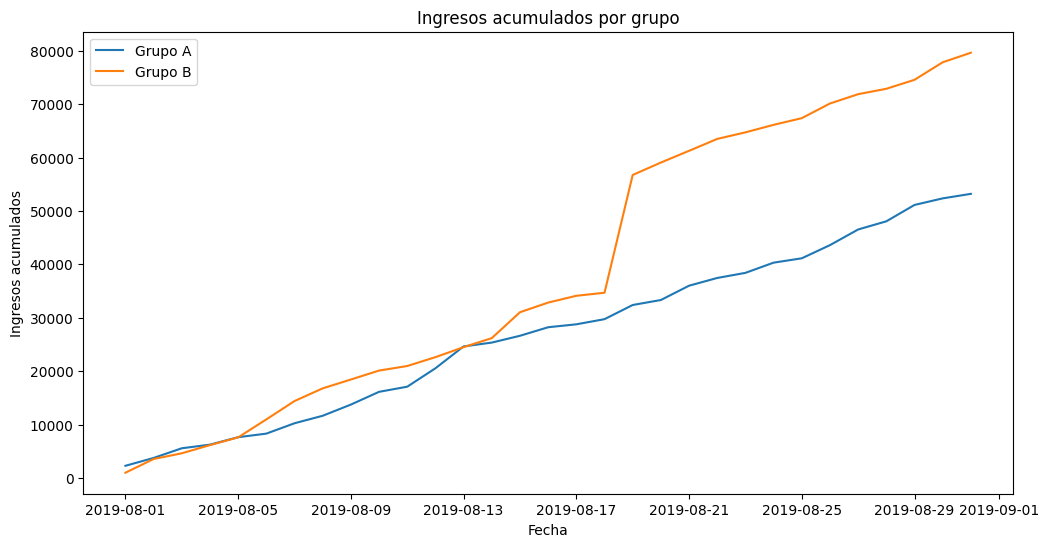

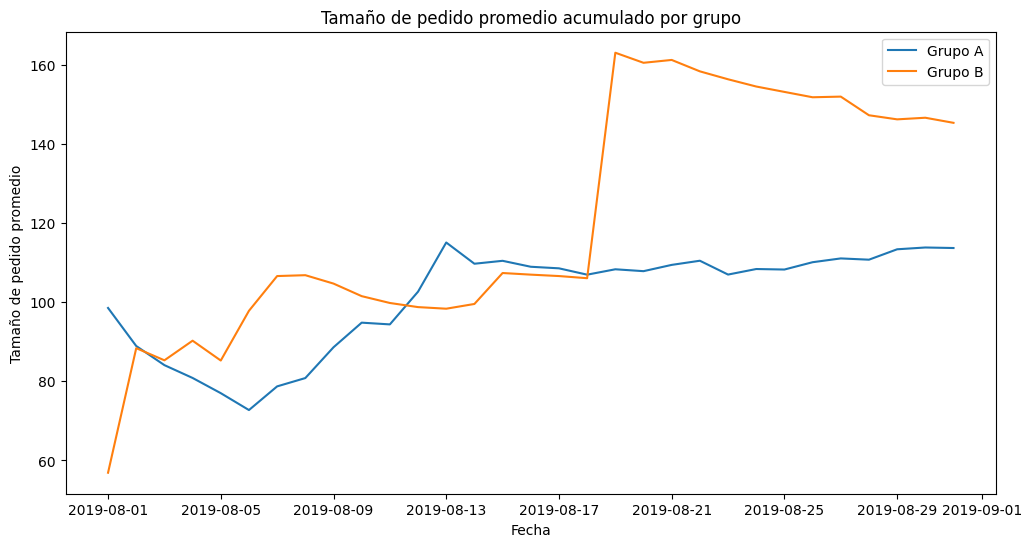

In [5]:
# Crear una tabla de pedidos y visitas acumuladas
dates_groups = orders_filtered[['date', 'group']].drop_duplicates()
orders_aggregated = dates_groups.apply(
    lambda x: orders_filtered[
        np.logical_and(
            orders_filtered['date'] <= x['date'], orders_filtered['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transactionId': 'nunique',
            'visitorId': 'nunique',
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])

visitors_aggregated = dates_groups.apply(
    lambda x: visits[
        np.logical_and(visits['date'] <= x['date'], visits['group'] == x['group'])
    ].agg({'date': 'max', 'group': 'max', 'visits': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])

cumulative_data = orders_aggregated.merge(
    visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulative_data.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visits',
]
# Gráfico de ingresos acumulados por grupo
cumulative_revenue_A = cumulative_data[cumulative_data['group'] == 'A'][['date', 'revenue']]
cumulative_revenue_B = cumulative_data[cumulative_data['group'] == 'B'][['date', 'revenue']]

plt.figure(figsize=(12, 6))
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue'], label='Grupo A')
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue'], label='Grupo B')
plt.title('Ingresos acumulados por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ingresos acumulados')
plt.legend()
plt.show()

# Gráfico del tamaño promedio de pedido acumulado por grupo
plt.figure(figsize=(12, 6))
plt.plot(
    cumulative_revenue_A['date'],
    cumulative_revenue_A['revenue'] / cumulative_data[cumulative_data['group'] == 'A']['orders'],
    label='Grupo A',
)
plt.plot(
    cumulative_revenue_B['date'],
    cumulative_revenue_B['revenue'] / cumulative_data[cumulative_data['group'] == 'B']['orders'],
    label='Grupo B',
)
plt.title('Tamaño de pedido promedio acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tamaño de pedido promedio')
plt.legend()
plt.show()

1. Ingreso acumulado por grupo
   -Ambos grupos tienen ingresos que crecen de manera constante.
   -El Grupo B tiene un crecimiento de ingresos consistentemente superior al Grupo A desde el inicio.
   -Alrededor del 18 de agosto, los ingresos del Grupo B experimentan un aumento brusco y significativo. Esto podría indicar un pedido muy grande o la llegada de un usuario muy valioso.
   -La brecha entre ambos grupos se mantiene, con el Grupo B liderando claramente al final de la prueba.
   Conjeturas: El salto arrepentido en el Grupo B sugiere la presencia de una o más anomalías (outliers) que inflan los ingresos de manera artificial. Sería importante investigar este pico para confirmar si un solo pedido o pocos pedidos caros son responsables de esta diferencia.

2. Tamaño de pedido promedio acumulado por grupo
    -Ambas líneas son volátiles al principio, lo cual es normal cuando hay pocos datos.
    -A partir del 15 de agosto, el tamaño de pedido promedio del Grupo B se dispara y se mantiene muy por encima del Grupo A.
    -El Grupo A muestra un crecimiento más lento y estable en su tamaño de pedido promedio.
    -La brecha en el tamaño de pedido promedio se mantiene amplia después del pico del Grupo B.
Conjeturas: Este gráfico refuerza la sospecha de la presencia de valores atípicos en el Grupo B. Un pedido extremadamente grande podría inflar el tamaño del pedido promedio acumulado y crear esta gran diferencia. Sin estos valores atípicos, la diferencia entre ambos grupos podría ser mucho menor.

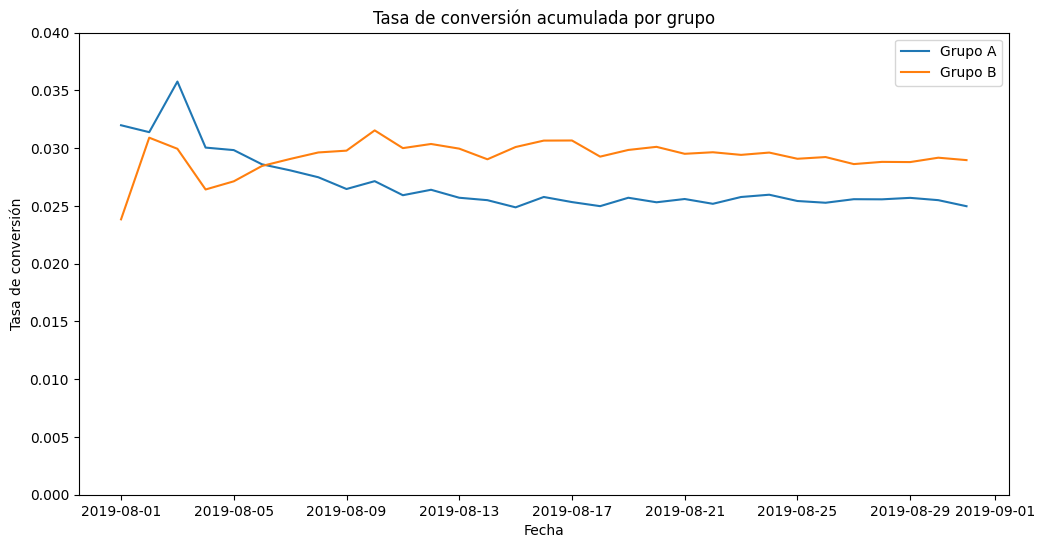

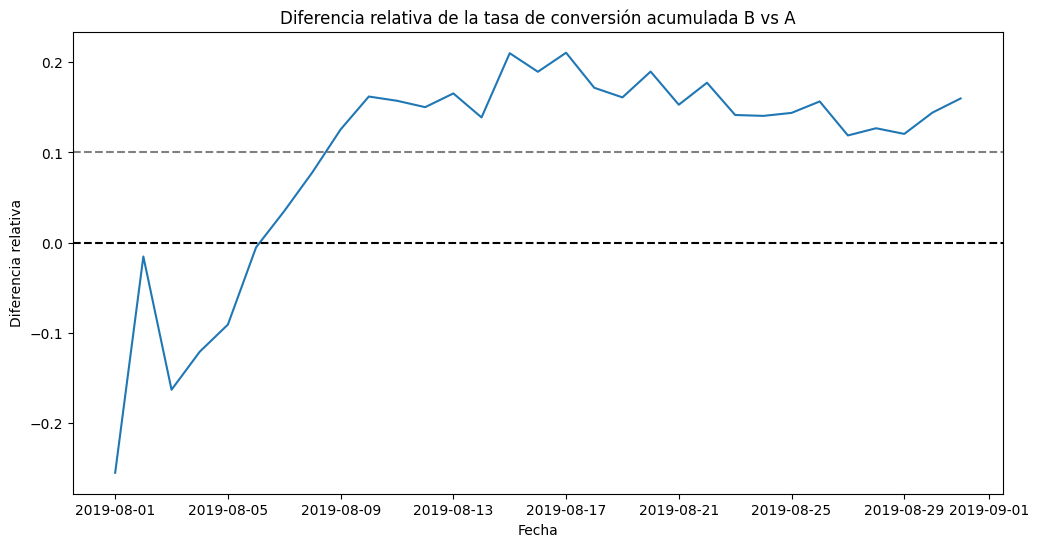

In [6]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

# Cargar los DataFrames y limpiar los usuarios que están en ambos grupos
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])
both_groups_users = np.intersect1d(orders[orders['group'] == 'A']['visitorId'].unique(), orders[orders['group'] == 'B']['visitorId'].unique())
orders_filtered = orders[~orders['visitorId'].isin(both_groups_users)]

# Prepara los datos acumulados para cada grupo por separado
cumulative_orders_A = orders_filtered[orders_filtered['group'] == 'A'][['date', 'revenue', 'transactionId', 'visitorId']].sort_values(by='date').groupby('date').agg({
    'revenue': 'sum',
    'transactionId': 'nunique',
    'visitorId': 'nunique'
}).reset_index().rename(columns={'transactionId': 'orders_A', 'visitorId': 'buyers_A', 'revenue': 'revenue_A'})
cumulative_visits_A = visits[visits['group'] == 'A'][['date', 'visits']].sort_values(by='date').groupby('date').sum().reset_index().rename(columns={'visits': 'visits_A'})

cumulative_orders_B = orders_filtered[orders_filtered['group'] == 'B'][['date', 'revenue', 'transactionId', 'visitorId']].sort_values(by='date').groupby('date').agg({
    'revenue': 'sum',
    'transactionId': 'nunique',
    'visitorId': 'nunique'
}).reset_index().rename(columns={'transactionId': 'orders_B', 'visitorId': 'buyers_B', 'revenue': 'revenue_B'})
cumulative_visits_B = visits[visits['group'] == 'B'][['date', 'visits']].sort_values(by='date').groupby('date').sum().reset_index().rename(columns={'visits': 'visits_B'})

# Fusiona los datos acumulados de ambos grupos
cumulative_data = cumulative_orders_A.merge(cumulative_visits_A, on='date', how='left').merge(cumulative_orders_B, on='date', how='left').merge(cumulative_visits_B, on='date', how='left')

# Rellena los valores NaN y calcula las sumas acumuladas
for column in ['orders_A', 'buyers_A', 'revenue_A', 'visits_A', 'orders_B', 'buyers_B', 'revenue_B', 'visits_B']:
    cumulative_data[column] = cumulative_data[column].fillna(0).cumsum()

# Tasas de conversión
cumulative_data['conversion_A'] = cumulative_data['orders_A'] / cumulative_data['visits_A']
cumulative_data['conversion_B'] = cumulative_data['orders_B'] / cumulative_data['visits_B']

# Grafica de las tasas de conversión acumuladas
plt.figure(figsize=(12, 6))
plt.plot(cumulative_data['date'], cumulative_data['conversion_A'], label='Grupo A')
plt.plot(cumulative_data['date'], cumulative_data['conversion_B'], label='Grupo B')
plt.title('Tasa de conversión acumulada por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.legend()
plt.ylim(0, 0.04)
plt.show()

# Grafica la diferencia relativa de la tasa de conversión
plt.figure(figsize=(12, 6))
plt.plot(
    cumulative_data['date'],
    cumulative_data['conversion_B'] / cumulative_data['conversion_A'] - 1,
)
plt.title('Diferencia relativa de la tasa de conversión acumulada B vs A')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa')
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')
plt.show()

1. Tasa de conversión acumulada por grupo
    -Al principio, el Grupo A tiene una tasa de conversión más alta, pero esta disminuye gradualmente.
    -La tasa de conversión del Grupo B comienza por debajo del Grupo A y luego se estabiliza.
    -A partir de la mitad de la prueba, la tasa del Grupo B se mantiene consistentemente por encima de la del Grupo A, y las líneas se separan. La línea del Grupo B es mucho más estable.
    Conjeturas: El rendimiento inicial del Grupo A podría deberse a un efecto inicial de la prueba, pero parece que el Grupo B tiene una tasa de conversión más sostenible y estable a largo plazo.

2. Diferencia relativa de la tasa de conversión acumulada
    -La diferencia relativa fluctuó al principio de la prueba.
    -A partir del 6 de agosto, el Grupo B comenzó a superar al Grupo A, y la diferencia se mantuvo en territorio positivo.
    -La diferencia a favor del Grupo B se ha estabilizado en un rango entre el 10% y el 20% a lo largo del tiempo, lo que sugiere que su conversión es consistentemente mejor.
    Conjeturas: El gráfico confirma que el Grupo B está superando consistentemente al Grupo A en términos de conversión, con una ventaja significativa. Las fluctuaciones iniciales han disminuido, lo que sugiere que los resultados son confiables.

La prueba parece exitosa, ya que se observa una clara diferencia entre los grupos.

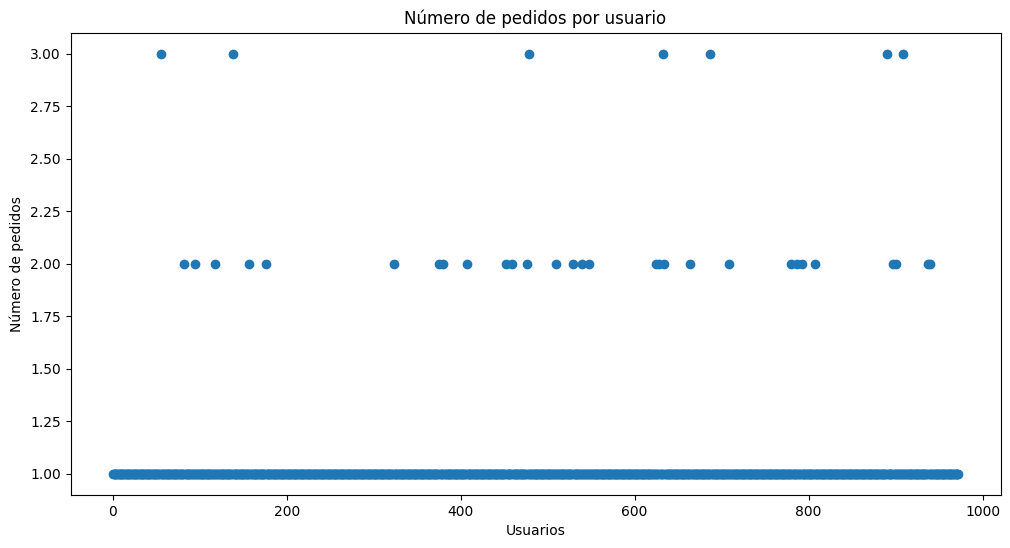

[1. 2.]


In [7]:
# Crea un DataFrame con el número de pedidos por usuario
orders_by_users = (
    orders_filtered.groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique})
)
orders_by_users.columns = ['visitorId', 'orders']

# Gráfico de dispersión del número de pedidos por usuario
x_values = pd.Series(range(0, len(orders_by_users)))
plt.figure(figsize=(12, 6))
plt.scatter(x_values, orders_by_users['orders'])
plt.title('Número de pedidos por usuario')
plt.xlabel('Usuarios')
plt.ylabel('Número de pedidos')
plt.show()

# Calcula los percentiles 95 y 99
print(np.percentile(orders_by_users['orders'], [95, 99]))

Análisis de pedidos por usuario
Conclusiones y conjeturas del gráfico de dispersión.
    -La mayoría de los usuarios realizaron un solo pedido . Hay un número muy pequeño de usuarios que hicieron dos pedidos, y una cantidad aún menor que hizo tres.
    -El gráfico muestra que los datos de los usuarios con más de un pedido se dispersan de manera notoria, lo que los convierte en candidatos a anomalías .

Percentiles y definición de anomalías
El percentil 95 indica que el 5% de los usuarios realizaron 2 o más pedidos.

El percentil 99 indica que solo el 1% de los usuarios realizó 3 o más pedidos.

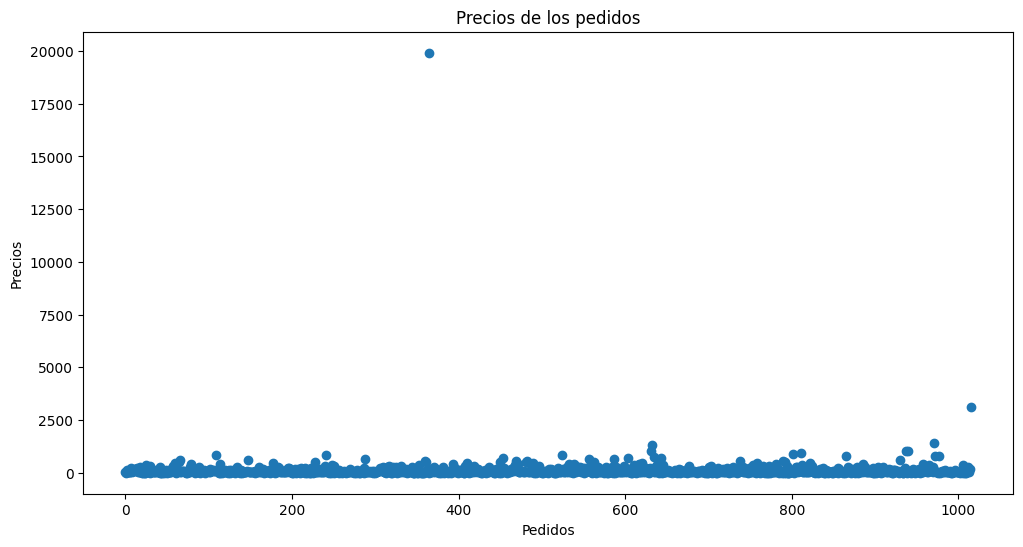

[414.275 830.3  ]


In [8]:
# Gráfico de dispersión de los precios de los pedidos
x_values = pd.Series(range(0, len(orders_filtered['revenue'])))
plt.figure(figsize=(12, 6))
plt.scatter(x_values, orders_filtered['revenue'])
plt.title('Precios de los pedidos')
plt.xlabel('Pedidos')
plt.ylabel('Precios')
plt.show()

# Calcula los percentiles 95 y 99 de los precios de los pedidos
print(np.percentile(orders_filtered['revenue'], [95, 99]))

Gráfico de precios de pedidos.
    -La gran mayoría de los pedidos tienen precios relativamente bajos, que se agrupan por debajo de los 2500 USD.
    -Hay unos pocos puntos de datos que se disparan muy por encima de este valor. Estos puntos representan pedidos con precios inusualmente altos, que podríamos considerar anomalías .

Percentiles y definición de anomalías
    -El percentil 95 $414.28) significa que el 5% de los pedidos son más caros que $414.28.
    -El percentil 99 $830.3) significa que el 1% de los pedidos son más caros que $830.3.

A pesar de que el percentil 99 es relativamente bajo, el gráfico muestra un gran salto en el precio después de este punto. Podemos considerar que un pedido es una anomalía si su precio es superior a $414.28 , eliminando así el 5% de los pedidos más caros.

Análisis de la significancia estadística (datos en bruto)
    -Valor p: El valor p es 0.01102 . Como este valor es menor que el umbral de 0.05 , podemos rechazar la hipótesis nula. Esto significa que la diferencia en la conversión entre el Grupo A y el Grupo B es estadísticamente significativa . No se debe al azar.
    -Ganancia relativa: El Grupo B tiene una ganancia relativa del 16% en la conversión en comparación con el Grupo A.

El Grupo B tiene una conversión significativamente más alta que el Grupo A. Esta diferencia no se debe a la aleatoriedad, y la mejora de más del 10% es considerable, sin embargo, este análisis inicial no considera la posible influencia de los valores atípicos.

In [10]:
import pandas as pd
import scipy.stats as stats

# Filtra los datos de ingresos para cada grupo, usando el DataFrame orders_filtered
revenueA = orders_filtered[orders_filtered['group'] == 'A']['revenue']
revenueB = orders_filtered[orders_filtered['group'] == 'B']['revenue']

# Calcula la significancia estadística y la diferencia relativa
p_value_revenue = stats.mannwhitneyu(revenueA, revenueB)[1]
relative_gain_revenue = revenueB.mean() / revenueA.mean() - 1

print(f"Valor p (tamaño de pedido): {p_value_revenue:.3f}")
print(f"Ganancia relativa del tamaño de pedido del Grupo B: {relative_gain_revenue:.3f}")

Valor p (tamaño de pedido): 0.862
Ganancia relativa del tamaño de pedido del Grupo B: 0.278


Análisis de la significancia estadística (datos en bruto)
Tamaño promedio de pedido
    -Valor p: El valor p es 0.862 . Dado que este valor es mucho mayor que el umbral de 0.05, no podemos rechazar la hipótesis nula. Esto significa que la diferencia en el tamaño promedio de pedido entre el Grupo A y el Grupo B no es estadísticamente significativa . La diferencia observada podría deberse al azar.
    -Ganancia relativa: El Grupo B tiene una ganancia relativa de casi el 28% sobre el Grupo A. Sin embargo, la prueba estadística indica que esta diferencia no es confiable.

1.- Conversión: La conversión del Grupo B es significativamente mejor que la del Grupo A.
2.- Tamaño de pedido: La diferencia en el tamaño promedio de pedido no es significativa , a pesar de que la ganancia relativa es grande.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien aplicadas las pruebas estadísticas, ahora el siguiente paso es revisar si quitando valores atípicos el resultado cambia de alguna manera
</div>

In [11]:
# DataFrame con el número de pedidos por usuario
ordersByUsers = (
    orders_filtered.groupby('visitorId', as_index=False)
    .agg({'transactionId': pd.Series.nunique})
)
ordersByUsers.columns = ['visitorId', 'orders']

# Lista de usuarios con más de 2 pedidos (percentil 99 = 3)
usersWithManyOrders = ordersByUsers[ordersByUsers['orders'] > 2]['visitorId']

# Lista de usuarios con pedidos caros (precio > 414.28)
usersWithExpensiveOrders = orders_filtered[orders_filtered['revenue'] > 414.28]['visitorId']

# Une las listas de usuarios anómalos y elimina duplicados
abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0).drop_duplicates()
print(f"Número de usuarios anómalos: {len(abnormalUsers)}")

Número de usuarios anómalos: 58


In [12]:
# DataFrames de pedidos por usuario para cada grupo, excluyendo a los usuarios anómalos
ordersByUsersA_filtered = orders_filtered[np.logical_and(
    orders_filtered['group'] == 'A',
    np.logical_not(orders_filtered['visitorId'].isin(abnormalUsers))
)].groupby('visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})
ordersByUsersA_filtered.columns = ['visitorId', 'orders']

ordersByUsersB_filtered = orders_filtered[np.logical_and(
    orders_filtered['group'] == 'B',
    np.logical_not(orders_filtered['visitorId'].isin(abnormalUsers))
)].groupby('visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})
ordersByUsersB_filtered.columns = ['visitorId', 'orders']

# Muestras filtradas para la prueba de Mann-Whitney
sampleA_filtered = pd.concat([
    ordersByUsersA_filtered['orders'],
    pd.Series(0, index=np.arange(visits[visits['group'] == 'A']['visits'].sum() - len(ordersByUsersA_filtered['orders'])), name='orders')
], axis=0)

sampleB_filtered = pd.concat([
    ordersByUsersB_filtered['orders'],
    pd.Series(0, index=np.arange(visits[visits['group'] == 'B']['visits'].sum() - len(ordersByUsersB_filtered['orders'])), name='orders')
], axis=0)

# Calcula la significancia estadística y la ganancia relativa
p_value_filtered = stats.mannwhitneyu(sampleA_filtered, sampleB_filtered)[1]
relative_gain_filtered = sampleB_filtered.mean() / sampleA_filtered.mean() - 1

print(f"Valor p (conversión, datos filtrados): {p_value_filtered:.5f}")
print(f"Ganancia relativa de la conversión del Grupo B (filtrado): {relative_gain_filtered:.3f}")

Valor p (conversión, datos filtrados): 0.01246
Ganancia relativa de la conversión del Grupo B (filtrado): 0.182


Análisis de la significancia estadística de la conversión (datos filtrados)
    -Valor p: El valor p es 0.01246 .
    -Ganancia relativa: La ganancia relativa de la conversión del Grupo B es 0,182 .
Conclusiones: El valor p de 0.01246 es menor que el umbral de 0.05, lo que significa que la diferencia en la conversión entre los grupos sigue siendo estadísticamente significativa incluso después de eliminar a los usuarios anómalos. La ganancia relativa del 18,2% del Grupo B con respecto al Grupo A también se mantiene, e incluso aumenta ligeramente en comparación con el resultado de los datos en bruto (16%). Esto demuestra que la superioridad del Grupo B no es un efecto de los datos atípicos, sino que es una diferencia real y confiable.

In [13]:
import pandas as pd
import scipy.stats as stats

# Filtra los datos de ingresos de cada grupo, excluyendo a los usuarios anómalos
revenueA_filtered = orders_filtered[np.logical_and(
    orders_filtered['group'] == 'A',
    np.logical_not(orders_filtered['visitorId'].isin(abnormalUsers))
)]['revenue']
revenueB_filtered = orders_filtered[np.logical_and(
    orders_filtered['group'] == 'B',
    np.logical_not(orders_filtered['visitorId'].isin(abnormalUsers))
)]['revenue']

# Calcula la significancia estadística y la ganancia relativa
p_value_revenue_filtered = stats.mannwhitneyu(revenueA_filtered, revenueB_filtered)[1]
relative_gain_revenue_filtered = revenueB_filtered.mean() / revenueA_filtered.mean() - 1

print(f"Valor p (tamaño de pedido, datos filtrados): {p_value_revenue_filtered:.3f}")
print(f"Ganancia relativa del tamaño de pedido del Grupo B (filtrado): {relative_gain_revenue_filtered:.3f}")

Valor p (tamaño de pedido, datos filtrados): 0.680
Ganancia relativa del tamaño de pedido del Grupo B (filtrado): -0.047


Análisis de la significancia estadística del tamaño del pedido (datos filtrados)
    -Valor p: El valor p de 0.680 es mucho mayor que 0.05. Esto significa que la diferencia en el tamaño de pedido promedio entre los grupos no es estadísticamente significativa .
    -Ganancia relativa: Después de eliminar las anomalías, la ganancia relativa del Grupo B se vuelve negativa (-4,7%) . Esto indica que, sin los pedidos inusualmente caros, el tamaño de pedido promedio del Grupo A es ligeramente superior.
    
El eliminarlas, la diferencia en el tamaño de pedido promedio se vuelve estadísticamente insignificante y, de hecho, el Grupo B ya no muestra una ventaja. Sin embargo, la conversión del Grupo B sigue siendo significativamente superior a la del Grupo A.

Resumen de los hallazgos

    -Gráficos acumulados : El Grupo B demostró un rendimiento superior en ingresos y conversión, aunque los picos en los gráficos de ingresos y tamaño de pedido sugerían la presencia de anomalías. El gráfico de diferencia relativa de la conversión mostró que el Grupo B se mantuvo consistentemente por encima del Grupo A.

    -Análisis de anomalías : Identificaste a los usuarios que hicieron 3 o más pedidos ya los pedidos con un precio superior a 414.28 USD como anomalías. En total, 58 usuarios fueron clasificados como anómalos.

Significancia estadística (datos brutos)

    -Conversión : La diferencia entre los grupos fue estadísticamente significativa (pag-valor = 0,011).

    -Tamaño del pedido : La diferencia no fue estadísticamente significativa (pag-valor = 0,862).

Significancia estadística (datos filtrados) :

    -Conversión : La diferencia siguió siendo estadísticamente significativa (pag-valor = 0,012), e incluso la ganancia relativa del Grupo B aumentó un 18,2%.

    -Tamaño del pedido : La diferencia se mantuvo no significativa (pag-valor = 0.680), y la ganancia relativa del Grupo B se volvió negativa (-4.7%), confirmando que las anomalías habían inflado la métrica.

    Decisión basada en los resultados de la prueba.
Basado en todos los análisis, la decisión final es: Parar la prueba, considere que el Grupo B es el grupo líder y concluya que la prueba es un éxito.